## Google Colab est disponible dans VS Code !
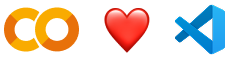

Essayez la nouvelle <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">extension Google Colab</a> pour Visual Studio Code. Vous pouvez vous lancer en quelques clics :

*  Dans VS Code, ouvrez la vue <strong><em>Extensions</em></strong> et recherchez "Google Colab" pour l'installer.
*  Ouvrez le sélecteur de kernel en créant ou en ouvrant un fichier de notebook <code>.ipynb</code> dans votre espace de travail local, puis en exécutant une cellule ou en cliquant sur le bouton <strong><em>Select Kernel</em></strong> &#40;Sélectionner le kernel&#41; en haut à droite.
*  Cliquez sur <strong><em>Colab</em></strong>, puis sélectionnez l'environnement d'exécution souhaité et connectez-vous avec votre compte Google. C'est tout !

Pour en savoir plus, consultez l'<a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">annonce sur notre blog</a>.

# Nouvelle section

# Nouvelle section

## 🎁 Forfait Pro sans frais pour Gemini et Colab pour les étudiants aux États-Unis 🎓

Bénéficiez d'un accès étendu à Gemini 3 Pro, notre modèle le plus précis. Profitez de ses capacités pour le codage avancé, les recherches complexes et les projets innovants, le tout avec les ressources de calcul hautes performances de Colab dédiées à la data science et au machine learning.

Profitez de l'offre Gemini sans frais sur <a href="https://gemini.google/students?utm_source=colab&amp;utm_medium=banner&amp;utm_campaign=students_xpa_us-colab-banner">gemini.google/students</a>.  
Profitez de l'offre Colab sans frais sur <a href="https://colab.research.google.com/signup">colab.research.google.com/signup</a>.  
Certaines conditions s'appliquent.

In [1]:
!pip install sdv pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Toutes les bibliothèques sont chargées')

✅ Toutes les bibliothèques sont chargées


In [4]:
real_data = pd.read_csv('diabetes.csv')

print(f'Forme du dataset : {real_data.shape}')
real_data.head()

Forme du dataset : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
real_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
real_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
print('Distribution Outcome (0 = non diabétique, 1 = diabétique) :')
print(real_data['Outcome'].value_counts())
print(f'\nTaux de diabète : {real_data["Outcome"].mean()*100:.2f}%')

Distribution Outcome (0 = non diabétique, 1 = diabétique) :
Outcome
0    500
1    268
Name: count, dtype: int64

Taux de diabète : 34.90%


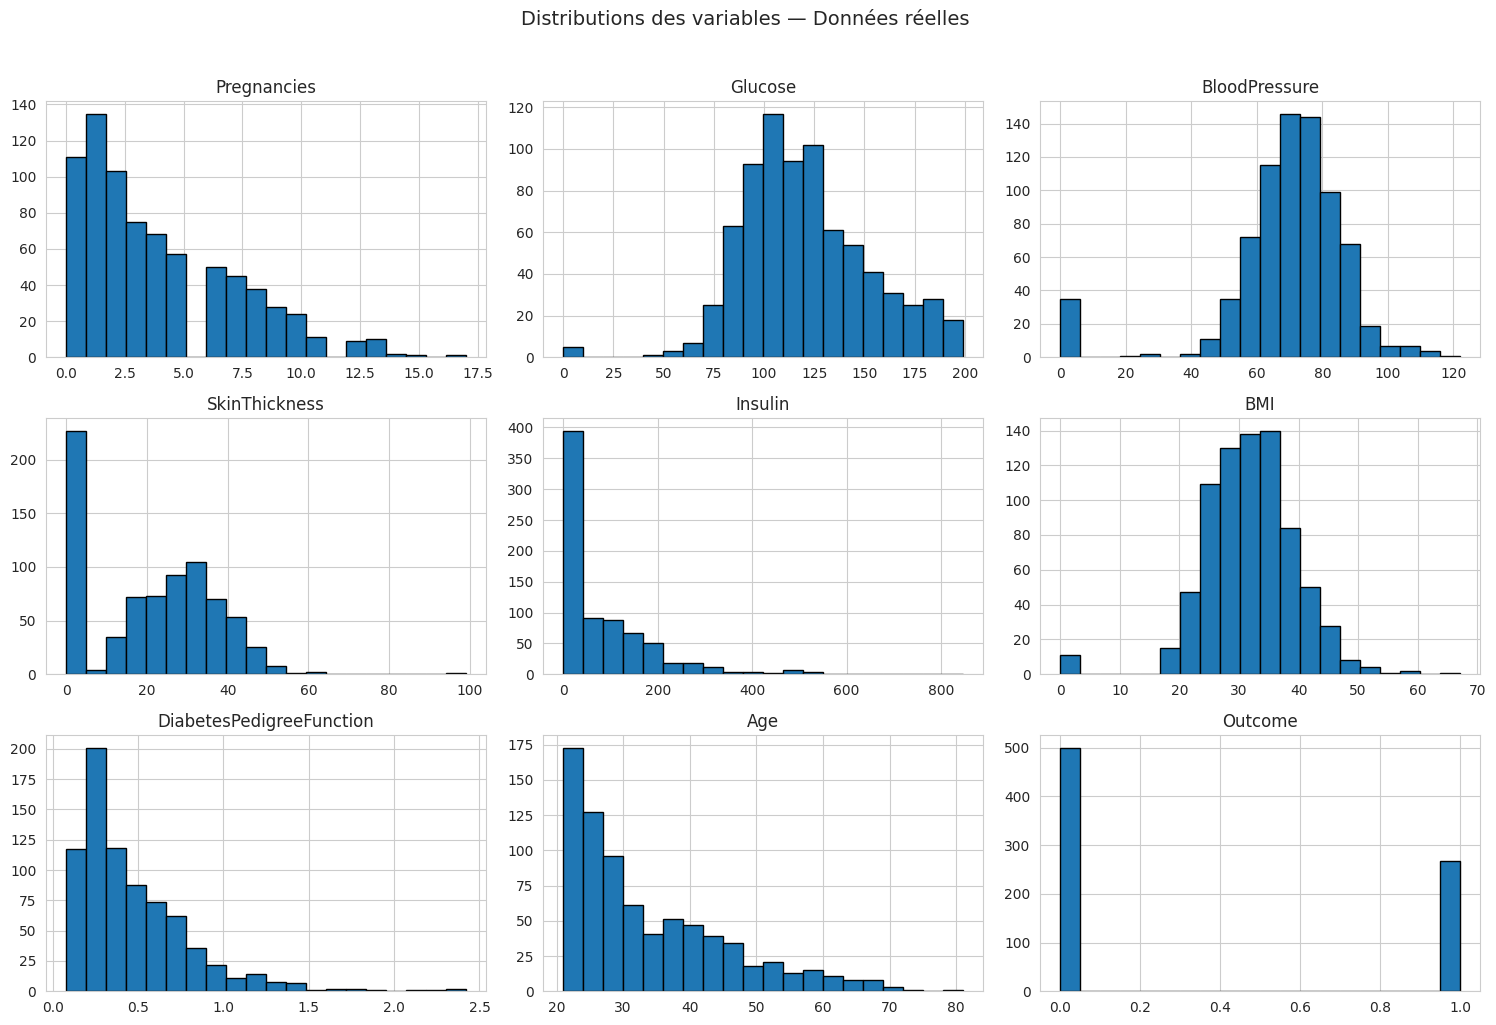

In [12]:
real_data.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle('Distributions des variables — Données réelles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('histograms_real.png', dpi=100, bbox_inches='tight')
plt.show()

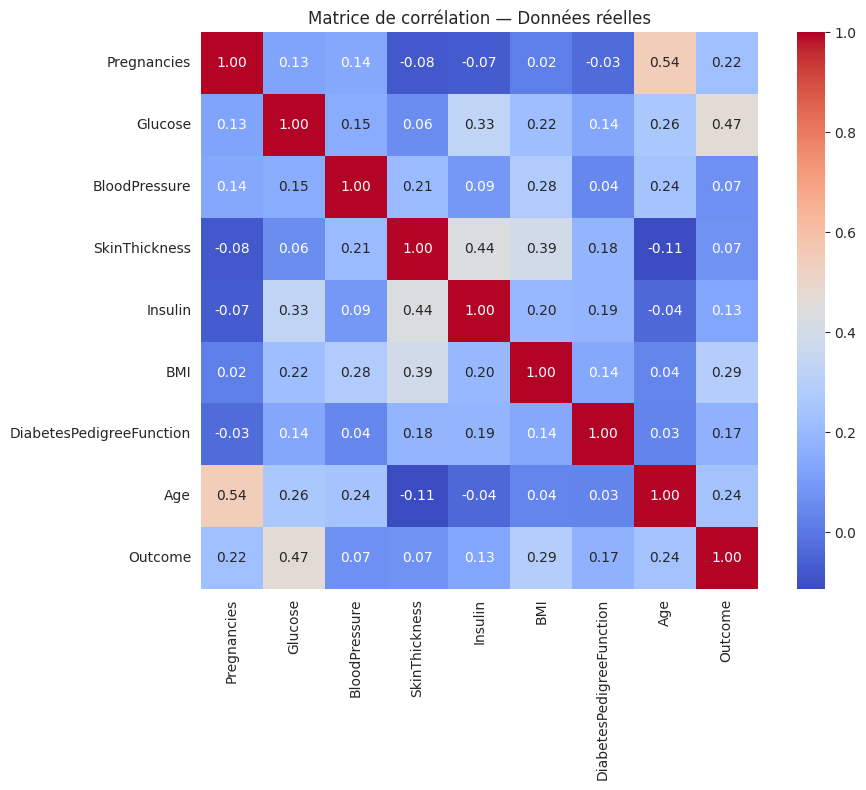

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(real_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matrice de corrélation — Données réelles')
plt.tight_layout()
plt.savefig('correlation_real.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

metadata.update_column(column_name='Outcome', sdtype='categorical')

print('Métadonnées détectées :')
print(metadata)

Métadonnées détectées :
{
    "columns": {
        "Pregnancies": {
            "sdtype": "numerical"
        },
        "Glucose": {
            "sdtype": "numerical"
        },
        "BloodPressure": {
            "sdtype": "numerical"
        },
        "SkinThickness": {
            "sdtype": "numerical"
        },
        "Insulin": {
            "sdtype": "numerical"
        },
        "BMI": {
            "sdtype": "numerical"
        },
        "DiabetesPedigreeFunction": {
            "sdtype": "numerical"
        },
        "Age": {
            "sdtype": "numerical"
        },
        "Outcome": {
            "sdtype": "categorical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}


In [16]:
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=100,
    verbose=True,
    cuda=False
)

print('✅ Synthétiseur CTGAN initialisé')

✅ Synthétiseur CTGAN initialisé


In [17]:
print('🔄 Entraînement en cours... (3-5 minutes)')
synthesizer.fit(real_data)
print('✅ Entraînement terminé')

🔄 Entraînement en cours... (3-5 minutes)


Gen. (-02.30) | Discrim. (+00.12): 100%|██████████| 300/300 [01:07<00:00,  4.46it/s]

✅ Entraînement terminé


In [18]:
synthetic_data = synthesizer.sample(num_rows=768)
print(f'Forme des données synthétiques : {synthetic_data.shape}')
synthetic_data.head()

Forme des données synthétiques : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,78,55,1,0,19.5,0.902,21,0
1,6,125,97,0,17,31.2,0.716,29,1
2,5,128,61,10,0,20.6,0.196,33,0
3,2,171,84,0,0,26.9,0.210,30,1
4,1,66,0,0,0,25.1,0.464,35,0


In [19]:
synthetic_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.971354,105.596354,64.33724,16.356771,48.623698,27.339453,0.427190,31.001302,0.486979
std,3.365863,37.073184,23.49345,15.005268,103.986524,8.504086,0.331963,10.512487,0.500156
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,77.000000,53.00000,1.000000,0.000000,20.875000,0.170000,22.000000,0.000000
50%,3.000000,102.000000,67.00000,14.000000,1.000000,26.000000,0.333000,28.000000,0.000000
75%,6.000000,132.000000,80.00000,27.000000,47.750000,32.600000,0.602250,36.000000,1.000000
max,17.000000,199.000000,122.00000,64.000000,760.000000,55.900000,1.726000,74.000000,1.000000


In [20]:
diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 1075.00it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 209.33it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [21]:
quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 391.01it/s]|
Column Shapes Score: 81.74%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 146.15it/s]|
Column Pair Trends Score: 75.16%

Overall Score (Average): 78.45%



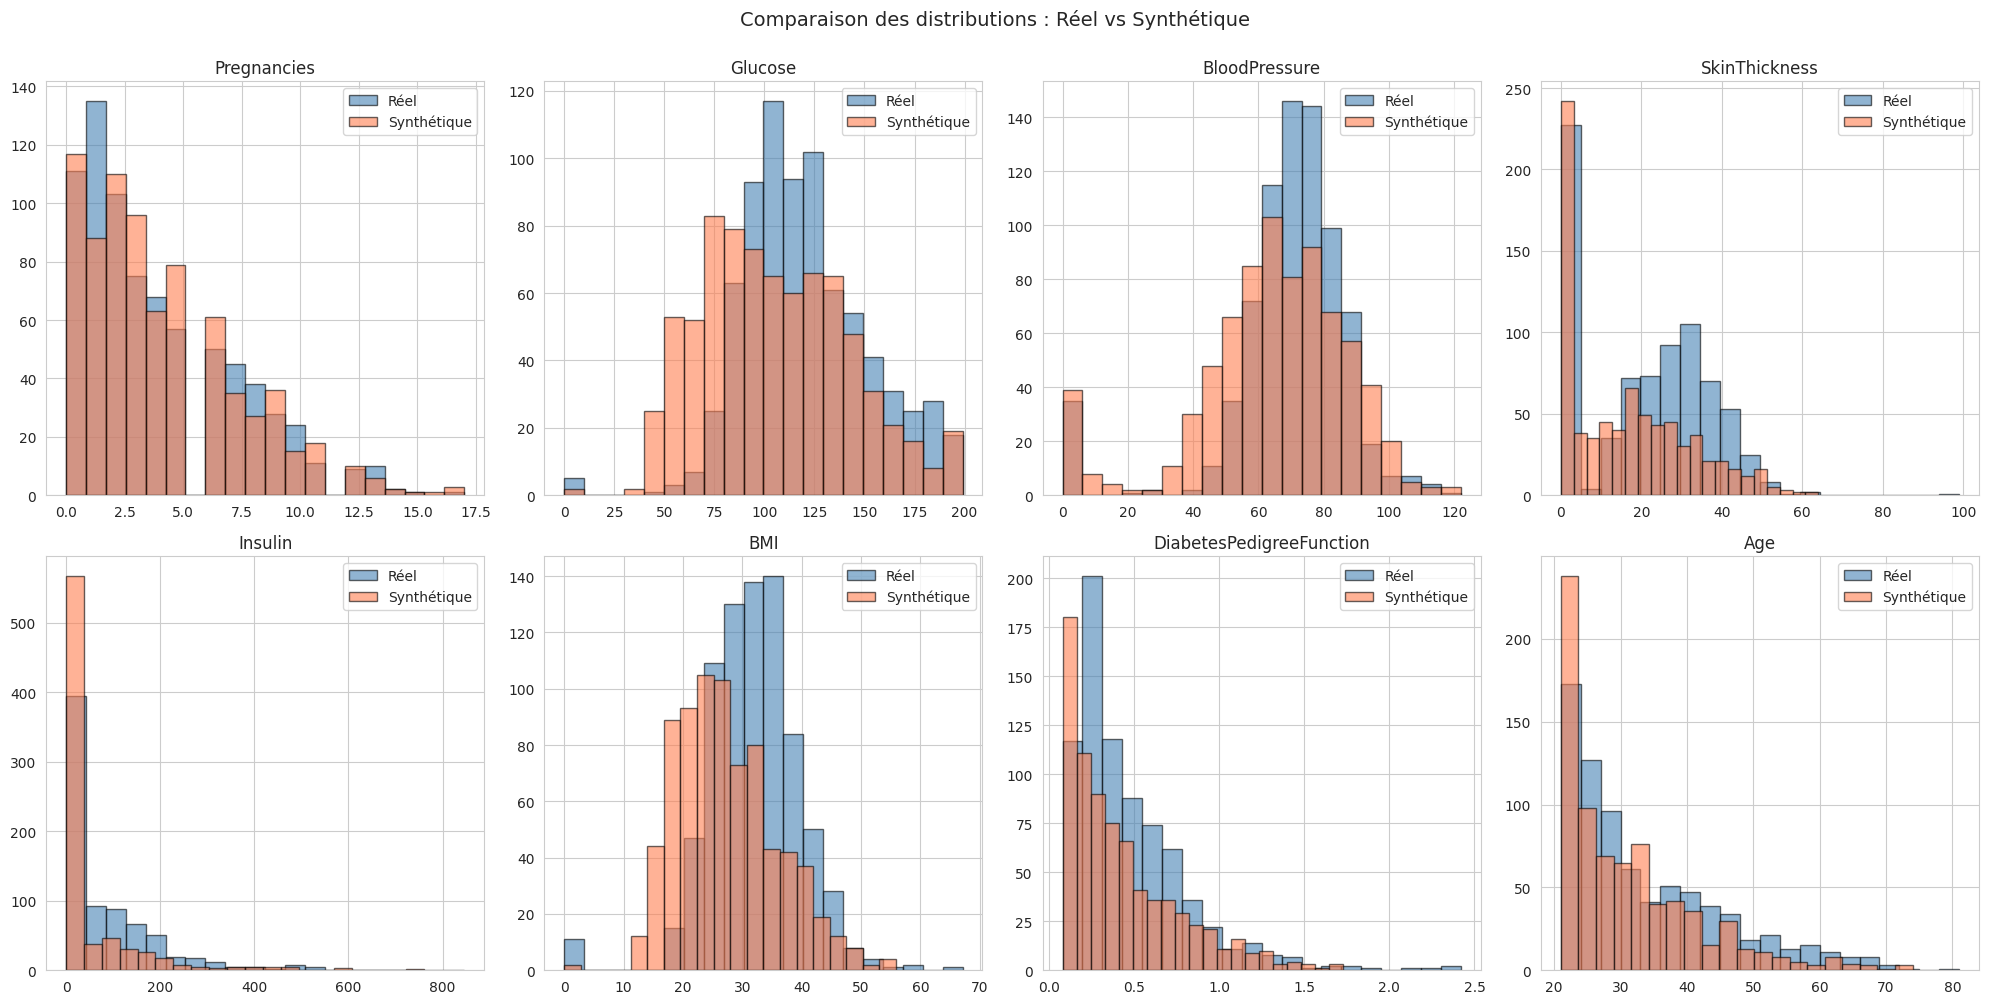

In [22]:
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(real_data[col], bins=20, alpha=0.6, label='Réel', color='steelblue', edgecolor='black')
    axes[i].hist(synthetic_data[col], bins=20, alpha=0.6, label='Synthétique', color='coral', edgecolor='black')
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()

plt.suptitle('Comparaison des distributions : Réel vs Synthétique', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('comparison_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

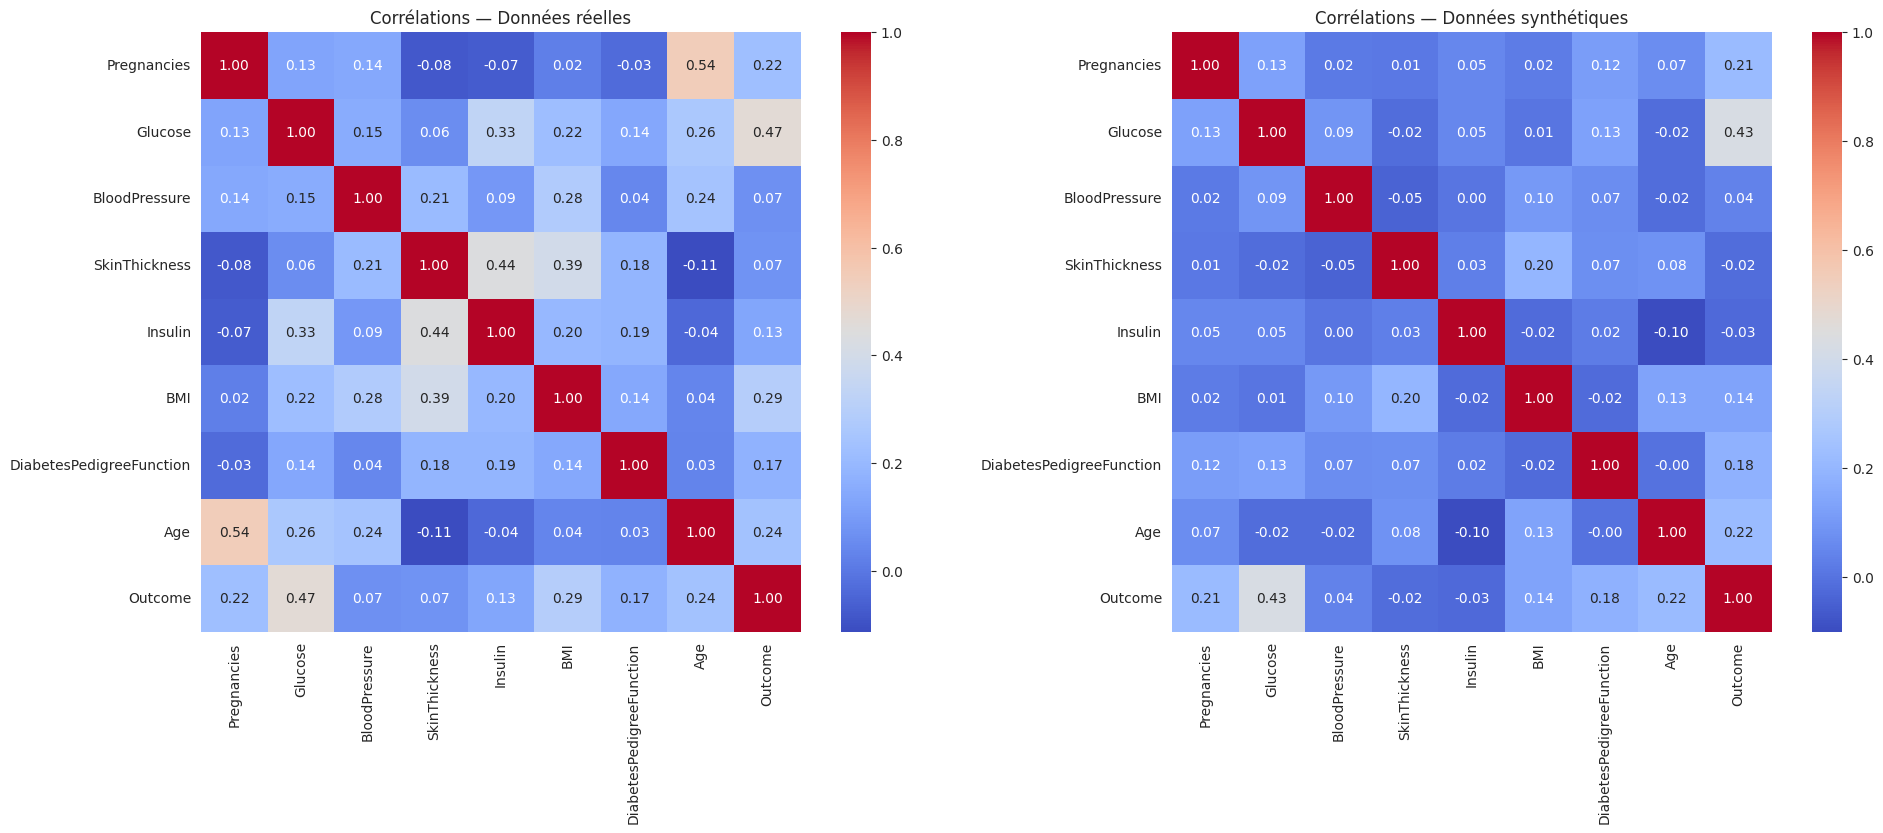

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(real_data.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            ax=axes[0], cbar=True, square=True)
axes[0].set_title('Corrélations — Données réelles')

sns.heatmap(synthetic_data.astype(float).corr(), annot=True, cmap='coolwarm', fmt='.2f',
            ax=axes[1], cbar=True, square=True)
axes[1].set_title('Corrélations — Données synthétiques')

plt.tight_layout()
plt.savefig('comparison_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
X_real = real_data.drop('Outcome', axis=1)
y_real = real_data['Outcome'].astype(int)

X_synth = synthetic_data.drop('Outcome', axis=1)
y_synth = synthetic_data['Outcome'].astype(int)

X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42, stratify=y_real
)

model_real = RandomForestClassifier(n_estimators=100, random_state=42)
model_real.fit(X_real_train, y_real_train)
acc_real = accuracy_score(y_real_test, model_real.predict(X_real_test))

model_synth = RandomForestClassifier(n_estimators=100, random_state=42)
model_synth.fit(X_synth, y_synth)
acc_synth = accuracy_score(y_real_test, model_synth.predict(X_real_test))

print('═══════════════════════════════════════════════════')
print('   RÉSULTATS DU TEST D\'UTILITÉ (TSTR)')
print('═══════════════════════════════════════════════════')
print(f'  Modèle entraîné sur RÉEL    → Accuracy : {acc_real:.4f}')
print(f'  Modèle entraîné sur SYNTH   → Accuracy : {acc_synth:.4f}')
print(f'  Écart relatif               : {abs(acc_real - acc_synth)*100:.2f} %')
print('═══════════════════════════════════════════════════')

═══════════════════════════════════════════════════
   RÉSULTATS DU TEST D'UTILITÉ (TSTR)
═══════════════════════════════════════════════════
  Modèle entraîné sur RÉEL    → Accuracy : 0.7489
  Modèle entraîné sur SYNTH   → Accuracy : 0.6840
  Écart relatif               : 6.49 %
═══════════════════════════════════════════════════


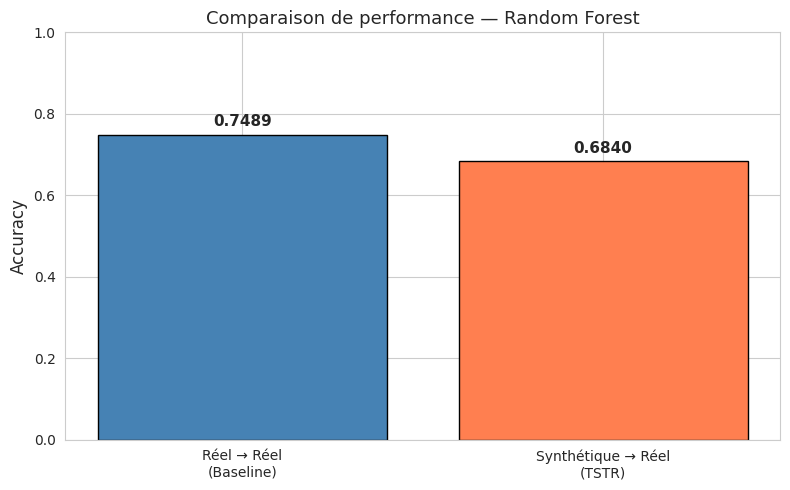

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Réel → Réel\n(Baseline)', 'Synthétique → Réel\n(TSTR)']
scores = [acc_real, acc_synth]
colors = ['steelblue', 'coral']

bars = ax.bar(models, scores, color=colors, edgecolor='black')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparaison de performance — Random Forest', fontsize=13)
ax.set_ylim(0, 1)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('tstr_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [26]:
synthetic_data.to_csv('diabetes_synthetic.csv', index=False)
print('✅ Données synthétiques sauvegardées dans diabetes_synthetic.csv')

synthesizer.save('ctgan_diabetes_model.pkl')
print('✅ Modèle CTGAN sauvegardé dans ctgan_diabetes_model.pkl')

✅ Données synthétiques sauvegardées dans diabetes_synthetic.csv
✅ Modèle CTGAN sauvegardé dans ctgan_diabetes_model.pkl


## Accéder aux modèles d'IA populaires via Google-Colab-AI sans clé API
Tous les utilisateurs ont accès aux LLM les plus populaires via la bibliothèque Python <code>google-colab-ai</code>, et les utilisateurs payants ont accès à une plus large sélection de modèles. Pour en savoir plus, consultez <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">Premiers pas avec l'IA Google Colab</a>.



## Découvrir l'API Gemini
L'API Gemini vous donne accès aux modèles Gemini créés par Google DeepMind. Les modèles Gemini ont été conçus dès le départ pour être multimodaux. Vous pouvez donc raisonner de manière fluide avec du texte, des images, du code et de l'audio.

**Lancez-vous avec les API Gemini**
*  Accédez à <a href="https://aistudio.google.com/">Google AI Studio</a> et connectez-vous avec votre compte Google.
*  <a href="https://aistudio.google.com/app/apikey">Créez une clé API.</a>
* Utilisez un guide de démarrage rapide pour <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a> ou appelez l'API REST à l'aide de <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Découvrez les fonctionnalités avancées de Gemini**
*  Testez les <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">sorties multimodales</a> de Gemini, qui associent le texte et les images de manière itérative.
*  Découvrez l'<a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">API Multimodal Live</a> &#40;<a href="https://aistudio.google.com/live">démonstration</a>&#41;.
*  Découvrez comment <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">analyser des images et détecter des éléments dans vos photos</a> à l'aide de Gemini &#40;existe aussi en <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">version 3D</a>&#41;.
*  Exploitez tout le potentiel du <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">modèle de réflexion Gemini</a>, capable de résoudre des tâches complexes grâce à ses pensées.
      
**Explorez des cas d'usages complexes**
*  Utilisez les <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">fonctionnalités d'ancrage de Gemini</a> pour créer un rapport sur une entreprise à l'aide de ce que le modèle peut trouver sur Internet.
*  Extrayez <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">les données de factures et de formulaires à partir de fichiers PDF</a> de manière structurée.
*  Créez des <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">illustrations à partir d'un livre entier</a> à l'aide de la grande fenêtre de contexte de Gemini et d'Imagen.

Pour en savoir plus, consultez le <a href="https://github.com/google-gemini/cookbook">livre de recettes Gemini</a> ou la <a href="https://ai.google.dev/docs/">documentation de l'API Gemini</a>.


Colab propose désormais des fonctionnalités d'IA fournies par <a href="https://gemini.google.com">Gemini</a>. La vidéo ci-dessous explique comment utiliser ces fonctionnalités, que vous soyez débutant ou utilisateur expérimenté de Python.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  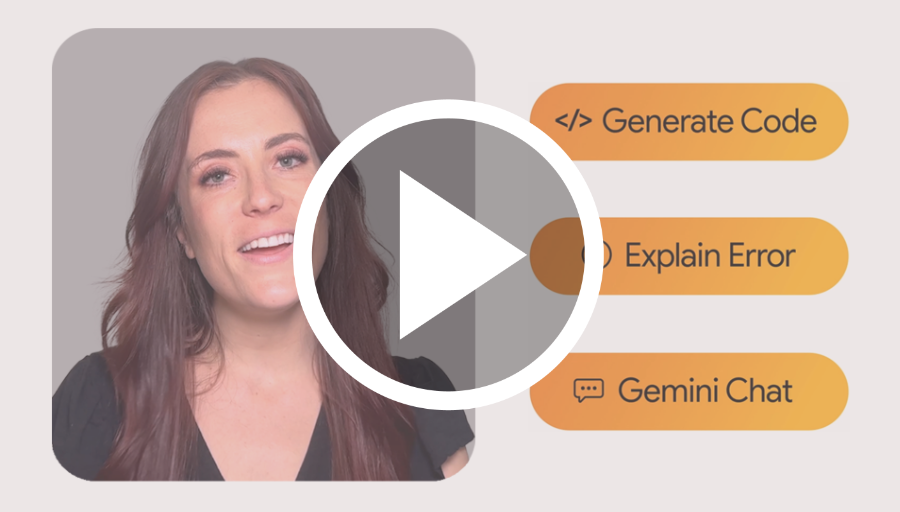
  </a>
</center>

<div class="markdown-google-sans">
  <h2>Qu'est-ce que Colab ?</h2>
</div>

Colab &#40;ou "Colaboratory"&#41; vous permet d'écrire et d'exécuter du code Python dans votre navigateur avec
- Aucune configuration requise
- Accès sans frais aux GPU
- Partage facile

Que vous soyez <strong>étudiant</strong>, <strong>data scientist</strong> ou <strong>chercheur en IA</strong>, Colab peut rendre votre travail plus simple. Regardez <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Introduction to Colab</a> &#40;Présentation de Colab&#41; ou <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Colab Features You May Have Missed</a> &#40;Connaissez-vous ces fonctionnalités Colab ?&#41; pour en savoir plus, ou lancez-vous ci-dessous.

<div class="markdown-google-sans">

## <strong>Premiers pas</strong>
</div>

Le document que vous consultez n'est pas une page Web statique, mais un environnement interactif appelé <strong>notebook Colab</strong>, qui vous permet d'écrire et d'exécuter du code.

Voici par exemple une <strong>cellule de code</strong> avec un bref script en Python qui calcule une valeur, l'enregistre dans une variable et imprime le résultat :

In [2]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Pour exécuter le code dans la cellule ci-dessus, sélectionnez-le en cliquant dessus, puis cliquez sur le bouton de lecture à gauche du code ou utilisez le raccourci clavier Commande/Ctrl+Entrée. Pour modifier le code, cliquez simplement sur la cellule.

Les variables que vous définissez dans une cellule peuvent être utilisées par la suite dans d'autres cellules :

In [3]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Les notebooks Colab vous permettent d'utiliser, dans un même document, du <strong>code exécutable</strong>, du <strong>texte enrichi</strong>, des <strong>images</strong>, du code <strong>HTML</strong>, du code <strong>LaTeX</strong> et bien plus. Lorsque vous créez des notebooks Colab, ils sont enregistrés dans votre compte Google Drive. Vous pouvez facilement les partager avec vos collaborateurs ou vos amis, qui peuvent alors y apporter des commentaires ou même les modifier. Pour en savoir plus, consultez la page <a href="/notebooks/basic_features_overview.ipynb">Présentation de Colaboratory</a>. Pour créer un notebook Colab, utilisez le menu "Fichier" ci-dessus ou le lien <a href="http://colab.research.google.com#create=true">Créer un notebook Colab</a>.

Les notebooks Colab sont des notebooks Jupyter hébergés par Colab. Pour en savoir plus sur le projet Jupyter, consultez le site Web <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Data science
</div>

Colab vous permet de tirer pleinement parti des bibliothèques populaires Python pour analyser et visualiser des données. La cellule de code ci-dessous utilise <strong>numpy</strong> pour générer des données aléatoires et <strong>matplotlib</strong> pour les visualiser. Pour modifier le code, cliquez simplement sur la cellule.

Vous pouvez importer vos propres données dans les notebooks Colab depuis votre compte Google Drive, y compris depuis des feuilles de calcul, ainsi que depuis GitHub et de nombreuses autres sources. Pour en savoir plus sur l'importation de données et l'utilisation de Colab dans le domaine de la data science, consultez les liens ci-dessous dans la section <a href="#working-with-data">Utiliser les données</a>.

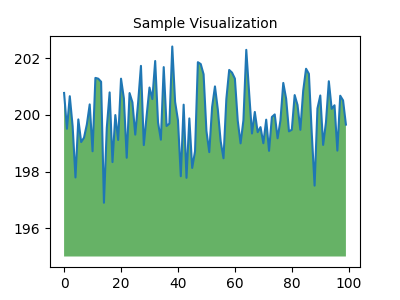

In [4]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Les notebooks Colab exécutent ce code sur les serveurs cloud de Google. Vous pouvez donc bénéficier de toute la puissance du matériel Google, y compris les <a href="#using-accelerated-hardware">GPU et TPU</a>, quelle que soit la puissance de votre ordinateur. Vous n'avez besoin que d'un navigateur.

Par exemple, si vous attendez que le code <strong>pandas</strong> termine de s'exécuter et que vous souhaitez accélérer le processus, vous pouvez passer à un environnement d'exécution GPU et utiliser des bibliothèques telles que <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a>, qui fournissent une accélération sans modification de code.

Pour en savoir plus sur l'accélération de pandas dans Colab, consultez le <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">guide de 10 minutes</a> ou la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">démo d'analyse des données boursières aux États-Unis</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Colab vous permet d'importer un ensemble de données d'images, d'entraîner un classificateur d'images sur cet ensemble et d'évaluer le modèle, tout cela avec <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">quelques lignes de code</a>.

Colab est très largement utilisé par la communauté du machine learning, par exemple dans les applications suivantes :
- Premiers pas avec TensorFlow
- Développement et entraînement de réseaux de neurones
- Expérimentation avec les TPU
- Dissémination de la recherche en IA
- Création de tutoriels

Pour voir comment les notebooks Colab sont utilisés dans des applications de machine learning, reportez-vous aux <a href="#machine-learning-examples">exemples de machine learning</a> ci-dessous.

<div class="markdown-google-sans">

## Autres ressources

### Utiliser les notebooks dans Colab

</div>

- [Présentation de Colab](/notebooks/basic_features_overview.ipynb)
- [Guide de Markdown](/notebooks/markdown_guide.ipynb)
- [Importer des bibliothèques et installer des dépendances](/notebooks/snippets/importing_libraries.ipynb)
- [Enregistrer et charger des notebooks dans GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulaires interactifs](/notebooks/forms.ipynb)
- [Widgets interactifs](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Utiliser les données
</div>

- [Chargement de données : Drive, Sheets et Google Cloud Storage](/notebooks/io.ipynb)
- [Graphiques : visualiser les données](/notebooks/charts.ipynb)
- [Premiers pas avec BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine learning

<div>

Voici quelques notebooks liés au machine learning, y compris le cours en ligne de Google sur ce sujet. Consultez la <a href="https://developers.google.com/machine-learning/crash-course/">formation complète en ligne</a> pour en savoir plus.
- [Présentation du DataFrame pandas](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Présentation de RAPIDS cuDF pour accélérer pandas](https://nvda.ws/rapids-cudf)
- [Premiers pas avec le mode accélérateur de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Utiliser le matériel accéléré
</div>

- [Entraîner un CNN à classer les chiffres manuscrits de l'ensemble de données MNIST à l'aide de l'API Flax NNX](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Entraîner un Vision Transformer &#40;ViT&#41; pour la classification d'images avec JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Classification de texte avec un modèle de langage Transformer utilisant JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Exemples

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Entraîner un modèle de langage miniGPT avec JAX AI Stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Affinage LoRA/QLoRA pour LLM avec Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Affinage d'un sous-ensemble de paramètres de Gemma avec LoRA et QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Chargement des points de contrôle Hugging Face Transformers</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Quantification d'entiers de 8 bits dans Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Entraînement et inférence Float8 avec un modèle Transformer simple</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Pré-entraînement d'un Transformer à partir de zéro avec KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST simple</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Classification d'images à partir de zéro à l'aide de Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Classification d'images avec KerasHub</a>
